## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
#Basic import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#Modelling
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
#from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [2]:
df=pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [4]:
X=df.drop(columns=['math_score'],axis=1)
y=df['math_score']

In [5]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [6]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [7]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [8]:
# Create Column Transformer with 3 types of transformers
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ('OneHot Encoder',oh_transformer,cat_features),
        ('Standard Scaler',numeric_transformer,num_features)
    ]
)

In [9]:
X=preprocessor.fit_transform(X)

In [10]:
X.shape

(1000, 19)

In [11]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [12]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
X_train.shape,X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [14]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    score=r2_score(true,predicted)
    return mae,mse,rmse,score

In [15]:
models={
    'Linear Regression':LinearRegression(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'K-Neighbors Regressor':KNeighborsRegressor(),
    'Decision Tree':DecisionTreeRegressor(),
    'Random Forest Regressor':RandomForestRegressor(),
    'XGBRegressor':XGBRegressor(),
    'AdaBoostRegressor':AdaBoostRegressor()
}
model_list=[] #Will store model names
r2_list=[] #Will store the test R² score of each model & Later you can use these lists to create a comparison table or graph

for i in range(len(list(models))): #Loop through all models,Repeat the following code once for every model in my dictionary.
    #Get the actual model
    model=list(models.values())[i] #models.values() gives you the actual model objects,[i] selects one model at a time.
    model.fit(X_train,y_train) #Train the model,Train the model using the training data.

    # Make predictions
    y_train_pred=model.predict(X_train) #Make predictions on training data,The model has already seen X_train,Using what you learned,predict the target values for X_train
    y_test_pred=model.predict(X_test) #Make predictions on test data,This is more important for evaluating how well the model generalizes.The model has not trained on X_test

    # Evaluate Train and Test dataset
    model_train_mae,model_train_mse,model_train_rmse,model_train_score=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_mse,model_test_rmse,model_test_score=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i]) #This adds the current model name to model_list.

    print('model performance for training set')
    print('mean absolute error:',model_train_mae)
    print('mean squared error:',model_train_mse)
    print('root mean squared error:',model_train_rmse)
    print('r2_score:',model_train_score)

    print('----------------------------------')
    print('model performance for test set')
    print('mean absolute error:',model_test_mae)
    print('mean squared error:',model_test_mse)
    print('root mean squared error:',model_test_rmse)
    print('r2_score:',model_test_score)
    r2_list.append(model_test_score) #This stores the test R² for the current model

    print('='*35)
    print('\n')






Linear Regression
model performance for training set
mean absolute error: 4.271484375
mean squared error: 28.4013037109375
root mean squared error: 5.329287354885032
r2_score: 0.874022530822051
----------------------------------
model performance for test set
mean absolute error: 4.2221875
mean squared error: 29.43263671875
root mean squared error: 5.425185408698029
r2_score: 0.8790464771743793


Ridge
model performance for training set
mean absolute error: 4.264987823725981
mean squared error: 28.33778823308244
root mean squared error: 5.323324922741654
r2_score: 0.8743042615212909
----------------------------------
model performance for test set
mean absolute error: 4.21110068801426
mean squared error: 29.056272192348278
root mean squared error: 5.390387016935637
r2_score: 0.8805931485028738


Lasso
model performance for training set
mean absolute error: 5.206302661246526
mean squared error: 43.47840400585577
root mean squared error: 6.593815587795565
r2_score: 0.8071462015863458
---

d:\Krish Naik Machine Learning Full Course\Projects\ML Project\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Krish Naik Machine Learning Full Course\Projects\ML Project\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\Krish Naik Machine Learning Full Course\Projects\ML Project\venv\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\Krish Naik Machine Learning Full Course\Projects\ML Project\venv\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\Krish Na

Random Forest Regressor
model performance for training set
mean absolute error: 1.8095541666666668
mean squared error: 5.244638675347222
root mean squared error: 2.290117611684435
r2_score: 0.9767367613192139
----------------------------------
model performance for test set
mean absolute error: 4.678233333333334
mean squared error: 36.18800122916666
root mean squared error: 6.015646368360316
r2_score: 0.851285283255061


XGBRegressor
model performance for training set
mean absolute error: 0.6874666035175323
mean squared error: 1.0146163961652577
root mean squared error: 1.0072816866027385
r2_score: 0.9954995444196413
----------------------------------
model performance for test set
mean absolute error: 5.057730598449707
mean squared error: 41.90370826987466
root mean squared error: 6.4733073671713335
r2_score: 0.8277965653186071


AdaBoostRegressor
model performance for training set
mean absolute error: 4.746721706094509
mean squared error: 33.596133124539485
root mean squared error: 5

In [16]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2 Score']).sort_values(by=['R2 Score'],ascending=False)

,Model Name,R2 Score
1,Ridge,0.880593
0,Linear Regression,0.879046
5,Random Forest Regressor,0.851285
7,AdaBoostRegressor,0.846678
6,XGBRegressor,0.827797
2,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.755813


## Linear Regression

In [17]:
lin_model=LinearRegression(fit_intercept=True) #fit_intercept_True means Let the model calculate the intercept (b₀) itself.
lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print('R2 Score of model is:',score)

R2 Score of model is: 87.90464771743794


## Plot y_pred and y_test

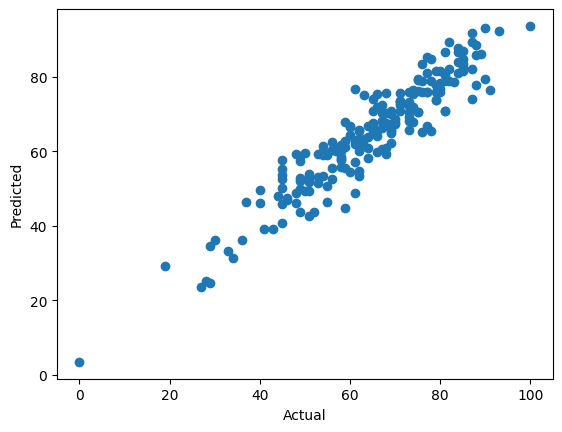

In [18]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

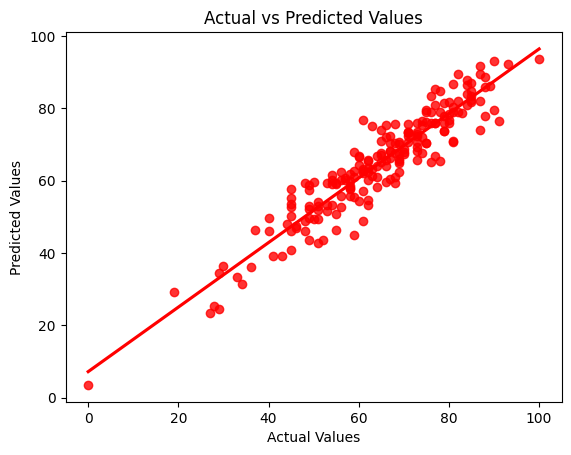

In [ ]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='red') #ci=None → removes the confidence interval/shaded region around the regression line.
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

plt.show()

#### Difference between Actual and Predicted Values

In [21]:
pred_df=pd.DataFrame({
    'Actual Values':y_test,
    'Predicted Values':y_pred,
    'Difference':y_test-y_pred
})

In [22]:
pred_df

,Actual Values,Predicted Values,Difference
521,91,76.4375,14.5625
737,53,59.3125,-6.3125
740,80,76.6250,3.3750
660,74,76.5625,-2.5625
411,84,87.7500,-3.7500
...,...,...,...
408,52,43.6875,8.3125
332,62,62.3125,-0.3125
208,74,67.7500,6.2500
613,65,67.0000,-2.0000
